In [183]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
    Created on Thu Jul 18 2025
    
    @author: Yaning
"""

import os
import torch
import pyro
from pyro.optim import Adam
import pyro.distributions as dist
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import seaborn as sns
import pickle
from pyro.infer import SVI, Trace_ELBO
import re
import pandas as pd

In [184]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [185]:
with open('/home/yaning/Documents/Discounting/results/array_cafe_gamble.pkl', 'rb') as f:
    data = pickle.load(f)

In [186]:
data = torch.tensor(data)

In [187]:
data = data.to(device)

In [188]:
data.shape

torch.Size([2, 30, 170, 8])

In [189]:
data = data[1]

In [190]:
def model(data):
    num_params = 4
    num_agents = data.shape[0]
    num_trials = data.shape[1]
    # define hyper priors over model parameters
    # prior over sigma of a Gaussian is a Gamma distribution
    a = pyro.param('a', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    lam = pyro.param('lam', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    tau = pyro.sample('tau', dist.Gamma(a, a/lam).to_event(1)) # mean = a / (a/lam) = lam

    sig = pyro.deterministic('sig', 1/torch.sqrt(tau)) # Gauss sigma

    # each model parameter has a hyperprior defining group level mean
    # in the form of a Normal distribution
    m = pyro.param('m', torch.zeros(num_params, device=device))
    s = pyro.param('s', torch.ones(num_params, device=device), constraint=dist.constraints.positive)
    mu = pyro.sample('mu', dist.Normal(m, s*sig).to_event(1)) # Gauss mu, wieso s*sig?

    # in order to implement groups, where each subject is independent of the others, pyro uses so-called plates.
    # you embed what should be done for each subject into the "with pyro.plate" context
    # the plate vectorizes subjects and adds an additional dimension onto all arrays/tensors
    # i.e. p1 below will have the length num_agents
    with pyro.plate('ag_idx', num_agents):
        # draw parameters from Normal and transform (for numeric trick reasons)
        # base_dist = dist.Normal(0., 1.).expand_by([num_params]).to_event(1)
        base_dist = dist.Normal(torch.zeros(num_params, device=device), torch.ones(num_params, device=device)).to_event(1)
        # Transform via the pointwise affine mapping y = loc + scale*x (-> Neal's funnel)
        transform = dist.transforms.AffineTransform(mu, sig)

        locs = pyro.sample('locs', dist.TransformedDistribution(base_dist, [transform]))
        # print(locs.shape)


    with pyro.plate('data', num_agents*num_trials):
        sigma_rate = torch.exp(locs[:,0]).unsqueeze(-1).expand(-1, num_trials)
        exp_a = torch.exp(locs[:,1]).unsqueeze(-1).expand(-1, num_trials)
        exp_b = torch.exp(locs[:,2]).unsqueeze(-1).expand(-1, num_trials)
        beta = torch.exp(locs[:,3]).unsqueeze(-1).expand(-1, num_trials)

        sigma_combine = sigma_rate/(1+exp_b*torch.exp(-exp_a*data[:,:,2]))

        e_mean = (data[:,:,3])/(sigma_combine**2 + 1)
        sum = e_mean + torch.tensor(20., device=device)

        softmax_args = torch.stack([beta*e_mean/sum, beta*torch.tensor(20., device=device)/sum])
        p = torch.softmax(softmax_args, dim = 0)[0]

    pyro.sample("obs", dist.Bernoulli(probs = p).to_event(2), obs=data[:,:,4])

    # return locs

In [191]:
def guide(data):
    num_params = 4
    num_agents = data.shape[0]
    # biject_to(constraint) looks up a bijective Transform from constraints.real 
    # to the given constraint. The returned transform is guaranteed to have 
    # .bijective = True and should implement .log_abs_det_jacobian().
    trns = torch.distributions.biject_to(dist.constraints.positive)

    # define mean vector and covariance matrix of multivariate normal
    m_hyp = pyro.param('m_hyp', torch.zeros(2*num_params, device=data.device))
    st_hyp = pyro.param('scale_tril_hyp',
                    torch.eye(2*num_params, device=data.device),
                    constraint=dist.constraints.lower_cholesky)

    # set hyperprior to be multivariate normal
    # scale_tril (Tensor) – lower-triangular factor of covariance, with positive-valued diagonal
    hyp = pyro.sample('hyp',
                    dist.MultivariateNormal(m_hyp, scale_tril=st_hyp),
                    infer={'is_auxiliary': True})

    # mu & tau unconstrained
    unc_mu = hyp[..., :num_params]
    unc_tau = hyp[..., num_params:]

    # constrained tau, shape num_params, or num_particles, 1, num_params
    c_tau = trns(unc_tau)

    # ld = log_density
    # log_abs_det_jacobian(x, y) computes derivative |dy/dx|
    ld_tau = -trns.inv.log_abs_det_jacobian(c_tau, unc_tau)
    
    # sum_rightmost(x, dim)
    # sum out ``dim`` many rightmost dimensions of a given tensor.
    # ld_tau.shape is num_params, or num_particles, 1, num_params before sum_rightmost
    ld_tau = dist.util.sum_rightmost(ld_tau, ld_tau.dim() - c_tau.dim() + 1)

    # some numerics tricks
    mu = pyro.sample("mu", dist.Delta(unc_mu, event_dim=1))
    # c_tau shape: num_params, or num_particles, 1, num_params
    # ld_tau shape: [] or num_particles, 1,
    tau = pyro.sample("tau", dist.Delta(c_tau, log_density=ld_tau, event_dim=1))

    m_locs = pyro.param('m_locs', torch.zeros(num_agents, num_params, device=data.device))
    st_locs = pyro.param('scale_tril_locs',
                    torch.eye(num_params, device=data.device).repeat(num_agents, 1, 1),
                    constraint=dist.constraints.lower_cholesky)
    
    with pyro.plate('ag_idx', num_agents):
        locs = pyro.sample("locs", dist.MultivariateNormal(m_locs, scale_tril=st_locs))

    return {'tau': tau, 'mu': mu, 'locs': locs, 'm_locs': m_locs, 'st_locs': st_locs}

Mean ELBO 3729.51:   0%|                                                              | 0/5000 [00:00<?, ?it/s]

Mean ELBO 1231.61: 100%|██████████████████████████████████████████████████| 5000/5000 [00:49<00:00, 100.74it/s]


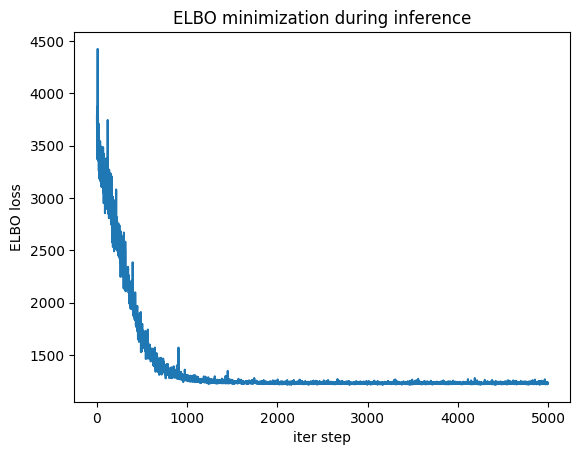

In [192]:
# this is for running the notebook in our testing framework
smoke_test = ('CI' in os.environ)
# the step was 2000
n_steps = 2 if smoke_test else 5000

# assert pyro.__version__.startswith('1.8.6')

# clear the param store in case we're in a REPL
pyro.clear_param_store()# setup the optimizer
# the learning rate was 0.0005 , "betas": (0.90, 0.999)
# tried "n_par":15 in adam params but it does not have this argument
adam_params = {"lr": 0.01}
optimizer = Adam(adam_params)
# setup the inference algorithm
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
# svi = SVI(model_gamma, guide_gamma, optimizer, loss=Trace_ELBO())

loss = []
pbar = tqdm(range(n_steps), position = 0)
# do gradient steps
for step in pbar:
    loss.append(torch.tensor(svi.step(data)))
    pbar.set_description("Mean ELBO %6.2f" % torch.tensor(loss[-20:]).mean())
    # for name, value in pyro.get_param_store().items():
    #     print(name, pyro.param(name))
    if torch.isnan(loss[-1]):
	    break

plt.figure()
plt.plot(loss)
plt.xlabel("iter step")
plt.ylabel("ELBO loss")
plt.title("ELBO minimization during inference")
plt.show()

In [193]:
for i in loss:
    print(i.numpy())

3778.1624
3618.785
3551.75
3613.4849
3509.8315
3873.5352
3368.8828
3826.133
4425.0024
3444.9536
3691.0928
3874.7932
3702.1653
3553.8186
3356.3594
3603.927
3635.5654
3712.2776
3423.7031
3548.5156
3412.2798
3260.4966
3501.2937
3510.1067
3280.3635
3445.9272
3527.3142
3378.5518
3183.6467
3425.0583
3346.4082
3412.366
3312.3374
3378.3052
3501.3171
3544.7488
3497.4429
3165.3293
3469.2017
3184.3606
3306.523
3198.6165
3320.1702
3446.369
3149.4624
3209.2805
3327.6184
3323.741
3255.3787
3453.3286
3390.2678
3105.4907
3384.8167
3490.1077
3153.2947
3145.8489
3422.188
3439.3347
3329.813
3279.104
3343.73
3315.361
3215.8647
3229.3665
3131.0146
3276.5708
3095.8943
3276.7722
3485.895
3175.3147
3309.085
3429.1003
3050.6553
3309.9124
3201.3755
2950.556
3169.7012
3157.72
3301.2732
3229.45
3255.82
3103.0757
3231.57
3114.2812
3175.5303
2997.8308
3102.865
3005.3599
3147.0464
2855.5273
3072.1501
3071.3225
3253.7998
3059.8809
3219.8428
3054.9167
3061.4263
3157.2747
3066.7031
3263.6501
3064.8481
2920.4446
3273.59

In [43]:
pos_dict = {}
for name, value in pyro.get_param_store().items():
    pos_dict[name] = value

# change the dictionary to numpy instead of tensor
# because somehow the tensor cannot be save with pickle
numpy_dict = {key: value.detach().cpu().numpy() for key, value in pos_dict.items()}

In [44]:
df_indiv = pd.DataFrame(numpy_dict["m_locs"], columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [45]:
df_mean = pd.DataFrame(numpy_dict["m"].reshape(1,4), columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [46]:
df_indiv.to_csv("/home/yaning/Documents/Discounting/paper/results/no_future_indiv_square.csv", index=False)

In [47]:
df_mean.to_csv("/home/yaning/Documents/Discounting/paper/results/no_future_mean_square.csv", index=False)

In [48]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/no_future_square.pkl', 'wb') as f:
    pickle.dump(numpy_dict, f)

Use guide to get the posterior (very important)

In [144]:
sample_num = 1000
tau = []
mu = []
locs = []
for i in range(sample_num):
    tau.append(guide(data)['tau'].detach().cpu().numpy())
    mu.append(guide(data)['mu'].detach().cpu().numpy())
    locs.append(guide(data)['locs'].detach().cpu().numpy())

In [145]:
tau = np.array(tau)
mu = np.array(mu)
locs = np.array(locs)

In [146]:
sample_dict = {}
sample_dict['tau'] = tau
sample_dict['mu'] = mu
sample_dict['locs'] = locs

In [147]:
# save the dictionary
with open('/home/yaning/Documents/Discounting/paper/results/future_samples.pkl', 'wb') as f:
    pickle.dump(sample_dict, f)

In [148]:
df = pd.DataFrame(mu, columns=['sigma_rate', 'exp_a', 'exp_b', 'beta'])

In [149]:
df.to_csv("/home/yaning/Documents/Discounting/paper/results/future_sample.csv", index=False)